### Observation

1. The predicted fare values generally follow the overall trend exhibited by the actual fare values, indicating that the model has successfully learned the underlying relationship between trip characteristics and fare amount.

2. Peaks and valleys observed in the actual fare series are reasonably captured by the predicted values, demonstrating the model's capability to estimate variations in fare amounts across different trips.

3. Minor deviations between the actual and predicted lines are present, suggesting that the model occasionally underestimates or overestimates certain fare values. These discrepancies are expected in regression tasks due to the inherent variability in real-world taxi trip data.

4. The close alignment between both curves across most samples indicates good predictive performance and supports the model's ability to generalize to unseen trips.

5. Larger gaps observed at some points may correspond to trips with uncommon characteristics, such as unusually long distances, heavy congestion periods, airport trips, or other factors influencing fare calculation that are difficult to capture perfectly.

6. Overall, the visualization suggests that the fare prediction model provides reliable fare estimates before ride initiation and is suitable for practical deployment scenarios.

# Use Case 2: Fare Prediction Evaluation and Inference

## Objective

The objective of this notebook is to evaluate the final fare prediction model using unseen test data and assess its prediction behavior.

This notebook focuses on:

- Final model evaluation
- Actual versus predicted fare analysis
- Residual diagnostics
- Feature importance interpretation
- Sample fare predictions
- Demonstration of inference using the saved model

# 1. Import Required Libraries

In [10]:
import warnings
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    None
)

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

# 2. Define Project Paths

In [11]:
PROJECT_DIR = Path(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE2_Trip_Fare_Forecasting"
)

MODEL_DIR = PROJECT_DIR / "models"

DATA_DIR = PROJECT_DIR / "data"

# 3. Load Saved Model

In [12]:
MODEL_PATH = (
    MODEL_DIR
    / "fare_prediction_pipeline.pkl"
)

In [13]:
saved_model = joblib.load(
    MODEL_PATH
)

In [14]:
best_model_name = saved_model[
    "model_name"
]

best_model = saved_model[
    "pipeline"
]

print(
    "Loaded Model:",
    best_model_name
)

Loaded Model: LightGBM


# 4. Load Saved Dataset Splits

Load the saved training, validation, and test datasets generated during model development.

In [15]:
X_test = pd.read_parquet(
    DATA_DIR / "X_test.parquet"
)

y_test = pd.read_parquet(
    DATA_DIR / "y_test.parquet"
).squeeze()

X_train = pd.read_parquet(
    DATA_DIR / "X_train.parquet"
)

y_train = pd.read_parquet(
    DATA_DIR / "y_train.parquet"
).squeeze()

In [16]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (2004306, 13)
X_test : (250539, 13)


# 5. Generate Predictions

In [17]:
train_predictions = best_model.predict(
    X_train
)

test_predictions = best_model.predict(
    X_test
)

# 6. Define Evaluation Metrics

In [18]:
def regression_metrics(
    y_true,
    y_pred
):

    return {
        "MAE":
        mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE":
        np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "R2":
        r2_score(
            y_true,
            y_pred
        )
    }

# 7. Model Performance Evaluation

In [19]:
train_metrics = regression_metrics(
    y_train,
    train_predictions
)

test_metrics = regression_metrics(
    y_test,
    test_predictions
)

In [20]:
performance_df = pd.DataFrame(
    [
        train_metrics,
        test_metrics
    ],
    index=[
        "Train",
        "Test"
    ]
)

performance_df

,MAE,RMSE,R2
Train,1.981277,3.528121,0.959007
Test,2.002389,3.581143,0.957770


### Observation

Comparable performance across training and test datasets indicates good generalization capability.

Significant performance degradation on the test set may indicate overfitting.

# 8. Actual vs Predicted Fare Analysis

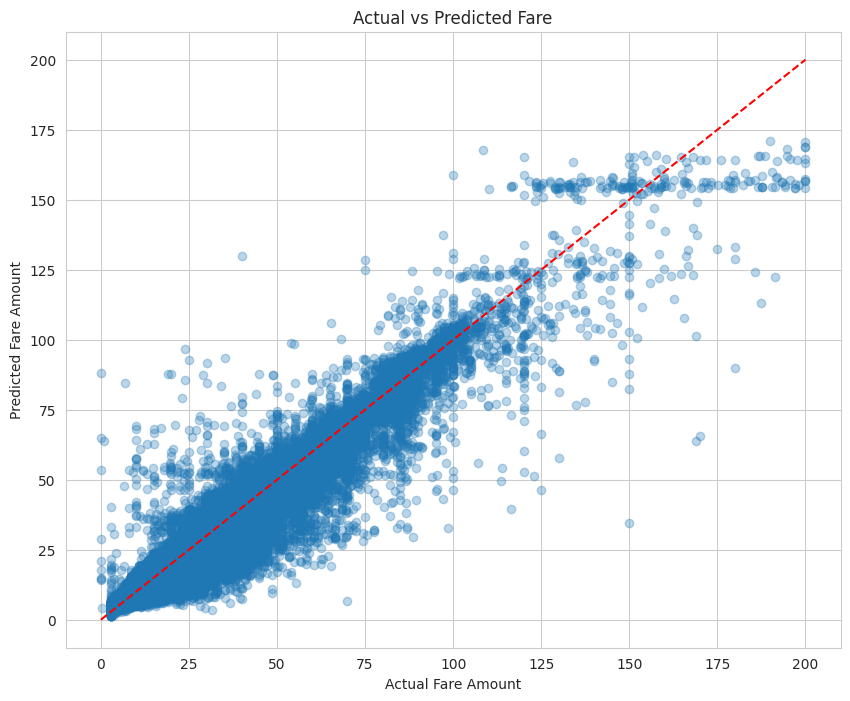

In [21]:
plt.figure(figsize=(10, 8))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.3
)

plt.plot(
    [
        y_test.min(),
        y_test.max()
    ],
    [
        y_test.min(),
        y_test.max()
    ],
    "r--"
)

plt.xlabel(
    "Actual Fare Amount"
)

plt.ylabel(
    "Predicted Fare Amount"
)

plt.title(
    "Actual vs Predicted Fare"
)

plt.show()

### Observation

Predictions located near the diagonal reference line indicate accurate fare estimation.

Larger deviations correspond to higher prediction errors.

# 9. Residual Analysis

In [22]:
residuals = (
    y_test
    - test_predictions
)

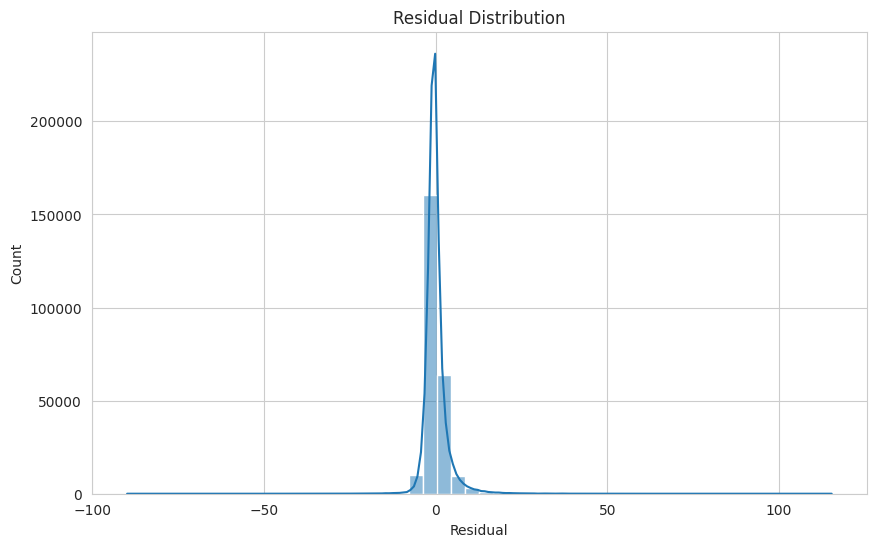

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.xlabel(
    "Residual"
)

plt.show()

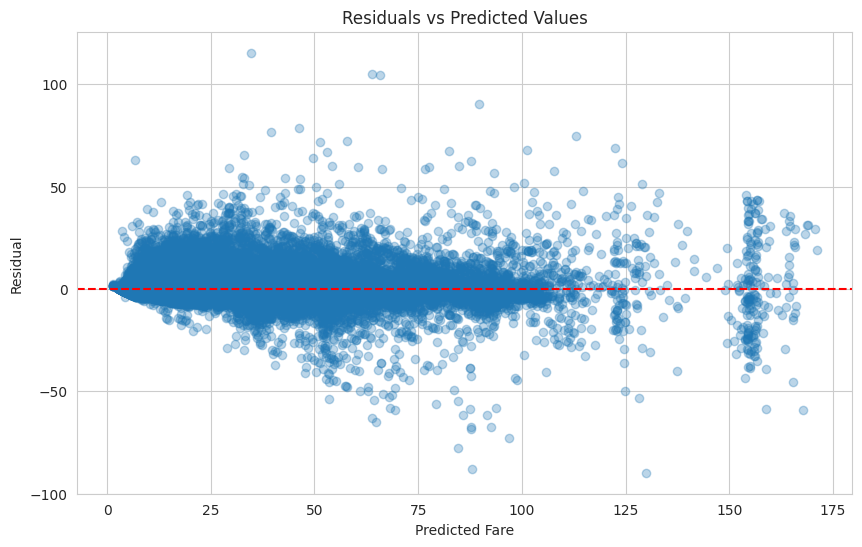

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    test_predictions,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel(
    "Predicted Fare"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residuals vs Predicted Values"
)

plt.show()

### Observation

Randomly distributed residuals centered around zero suggest that the model effectively captures underlying fare patterns.

Systematic structures may indicate model bias.

# 10. Overfitting Assessment

In [25]:
r2_gap = (
    train_metrics["R2"]
    - test_metrics["R2"]
)

rmse_gap = (
    test_metrics["RMSE"]
    - train_metrics["RMSE"]
)

print(
    f"R² Gap: {r2_gap:.4f}"
)

print(
    f"RMSE Gap: {rmse_gap:.4f}"
)

R² Gap: 0.0012
RMSE Gap: 0.0530


In [26]:
if (
    train_metrics["R2"] > 0.95
    and r2_gap > 0.10
):

    print(
        "⚠️ Potential Overfitting Detected"
    )

elif (
    train_metrics["R2"] < 0.70
    and test_metrics["R2"] < 0.70
):

    print(
        "⚠️ Potential Underfitting Detected"
    )

else:

    print(
        "✅ Model Generalizes Well"
    )

✅ Model Generalizes Well


# 11. Feature Importance Analysis

In [27]:
model = best_model.named_steps[
    "model"
]

In [28]:
if hasattr(
    model,
    "feature_importances_"
):

    feature_names = (
        best_model
        .named_steps[
            "preprocessor"
        ]
        .get_feature_names_out()
    )

    importance_df = pd.DataFrame(
        {
            "Feature":
            feature_names,

            "Importance":
            model.feature_importances_
        }
    )

    importance_df = (
        importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
        .head(20)
    )

    display(
        importance_df
    )

,Feature,Importance
1,num__trip_distance,2294
2,num__RatecodeID,1661
4,num__pickup_hour,1065
5,num__pickup_dayofweek,698
3,num__cbd_congestion_fee,406
467,cat__DOLocationID_265,201
3768,cat__Location_Pair_infrequent_sklearn,180
113,cat__PULocationID_132,170
119,cat__PULocationID_138,123
234,cat__DOLocationID_1,116


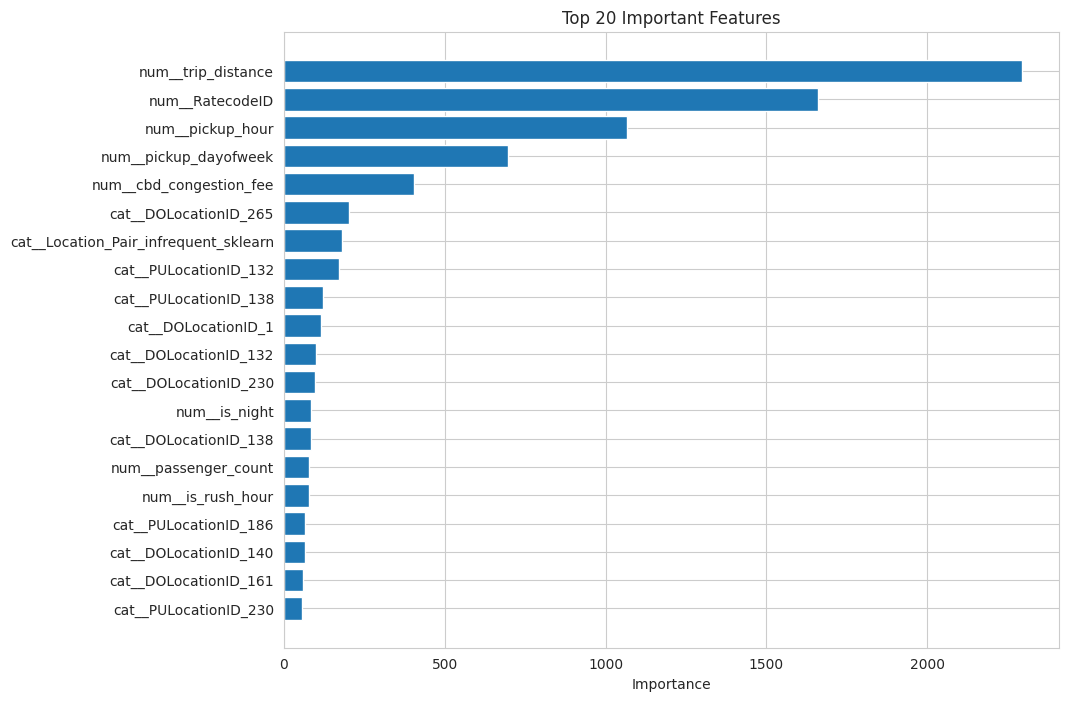

In [29]:
plt.figure(figsize=(10, 8))

plt.barh(
    importance_df[
        "Feature"
    ][::-1],

    importance_df[
        "Importance"
    ][::-1]
)

plt.title(
    "Top 20 Important Features"
)

plt.xlabel(
    "Importance"
)

plt.show()

# 12. Sample Predictions

In [30]:
samples = X_test.sample(
    n=5,
    random_state=42
)

sample_predictions = best_model.predict(
    samples
)

In [31]:
samples_output = samples.copy()

samples_output[
    "Predicted Fare"
] = sample_predictions

samples_output

,passenger_count,trip_distance,RatecodeID,cbd_congestion_fee,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,PULocationID,DOLocationID,Location_Pair,Predicted Fare
131794,1.0,2.11,1.0,0.75,19,6,1,1,1,0,233,90,233_90,13.657222
61975,1.0,1.38,1.0,0.75,11,5,1,1,0,0,161,234,161_234,10.846394
201089,1.0,1.40,1.0,0.75,17,5,1,1,1,0,170,163,170_163,13.043021
127352,1.0,24.92,4.0,0.00,14,5,1,1,0,0,132,265,132_265,123.014754
222945,1.0,2.79,1.0,0.00,0,4,1,0,0,1,263,237,263_237,15.570313


# 13. Inference Demonstration

In [32]:
example_trip = pd.DataFrame(
    {
        "passenger_count": [2],
        "trip_distance": [5.5],
        "RatecodeID": [1],
        "cbd_congestion_fee": [2.5],
        "pickup_hour": [18],
        "pickup_dayofweek": [4],
        "pickup_month": [6],
        "is_weekend": [0],
        "is_rush_hour": [1],
        "is_night": [0],
        "PULocationID": [237],
        "DOLocationID": [161],
        "Location_Pair": ["237_161"]
    }
)

In [33]:
predicted_fare = best_model.predict(
    example_trip
)

print(
    f"Predicted Fare: ${predicted_fare[0]:.2f}"
)

Predicted Fare: $30.61


# Actual vs Predicted Fare Comparison

This visualization compares actual fare amounts with model predictions on the test dataset.

The chart helps assess how closely the predicted fares follow the true fare values across different observations.

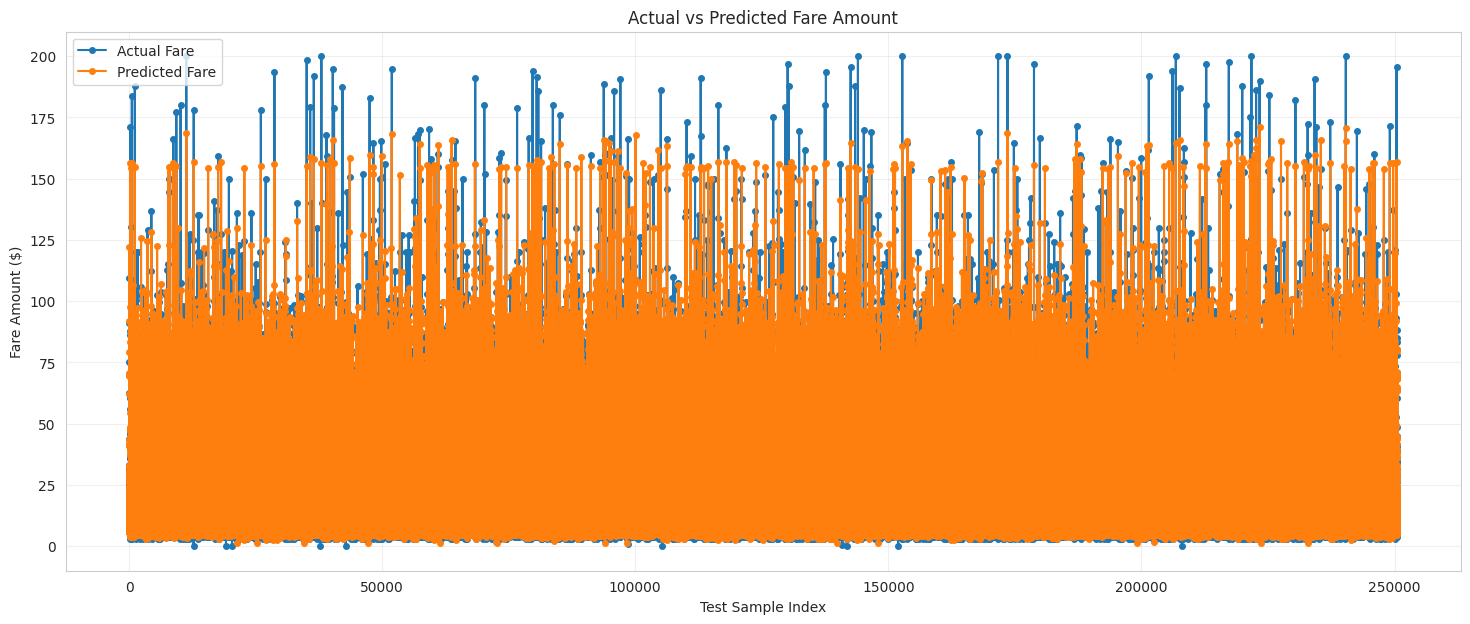

In [34]:
# Create comparison DataFrame
fare_comparison = pd.DataFrame({
    "Actual Fare": y_test.reset_index(drop=True),
    "Predicted Fare": test_predictions
})

# Plot
plt.figure(figsize=(18, 7))

plt.plot(
    fare_comparison.index,
    fare_comparison["Actual Fare"],
    marker='o',
    markersize=4,
    label='Actual Fare'
)

plt.plot(
    fare_comparison.index,
    fare_comparison["Predicted Fare"],
    marker='o',
    markersize=4,
    label='Predicted Fare'
)

plt.title(
    "Actual vs Predicted Fare Amount"
)

plt.xlabel(
    "Test Sample Index"
)

plt.ylabel(
    "Fare Amount ($)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

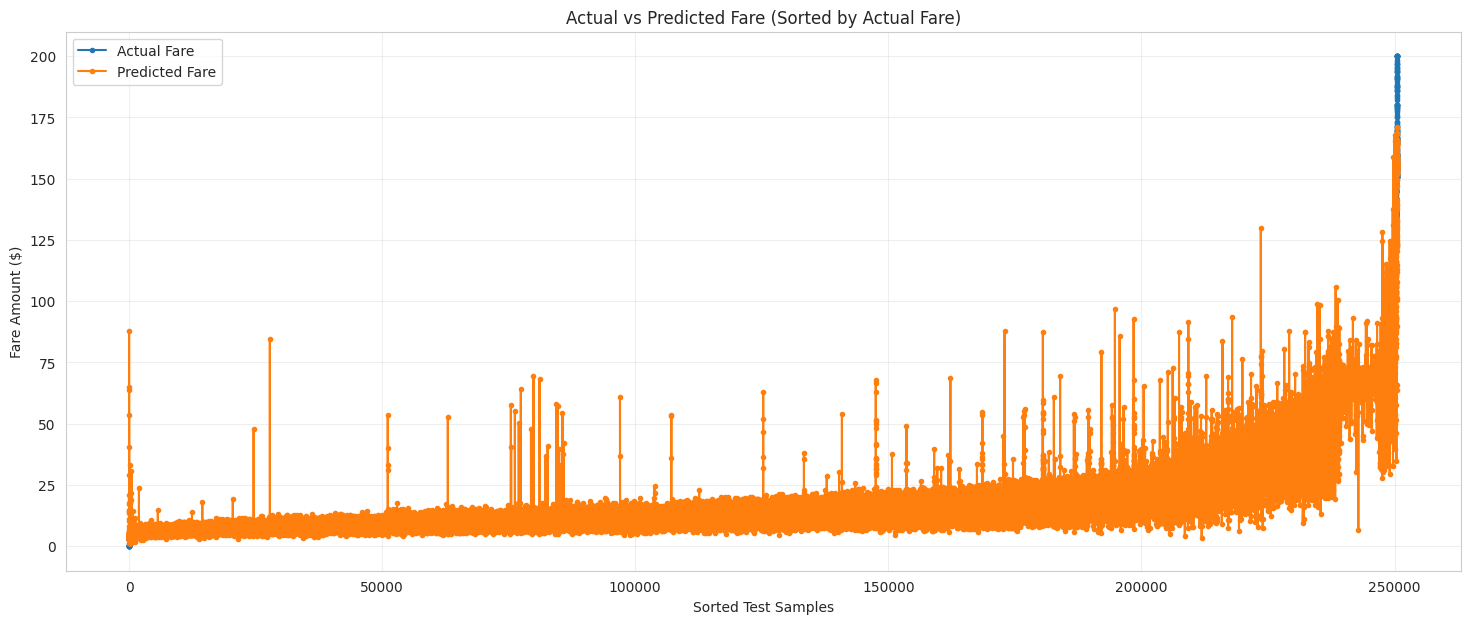

In [35]:
fare_comparison = pd.DataFrame({
    "Actual Fare": y_test.values,
    "Predicted Fare": test_predictions
})

# Sort by actual fare
fare_comparison = fare_comparison.sort_values(
    by="Actual Fare"
).reset_index(drop=True)

plt.figure(figsize=(18, 7))

plt.plot(
    fare_comparison["Actual Fare"],
    label="Actual Fare",
    marker='o',
    markersize=3
)

plt.plot(
    fare_comparison["Predicted Fare"],
    label="Predicted Fare",
    marker='o',
    markersize=3
)

plt.title(
    "Actual vs Predicted Fare (Sorted by Actual Fare)"
)

plt.xlabel(
    "Sorted Test Samples"
)

plt.ylabel(
    "Fare Amount ($)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

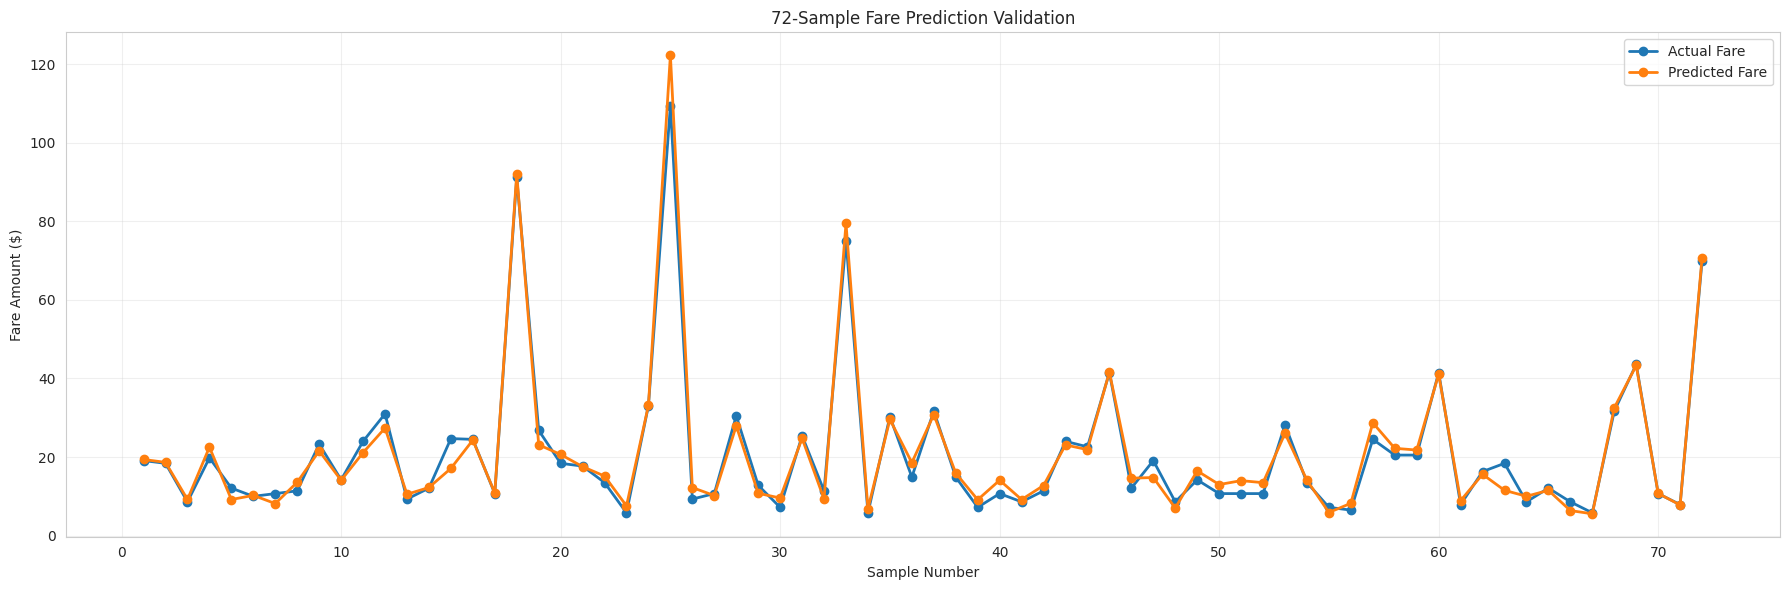

In [41]:
# Create comparison dataframe
fare_comparison = pd.DataFrame({
    "Actual Fare": y_test.values,
    "Predicted Fare": test_predictions
})

# Select a subset (e.g., first 72 samples)
plot_df = fare_comparison.head(72).reset_index(drop=True)

# Create pseudo-time labels similar to forecasting plots
plot_df["Sample"] = range(1, len(plot_df) + 1)

plt.figure(figsize=(18, 6))

plt.plot(
    plot_df["Sample"],
    plot_df["Actual Fare"],
    marker='o',
    linewidth=2,
    markersize=6,
    label='Actual Fare'
)

plt.plot(
    plot_df["Sample"],
    plot_df["Predicted Fare"],
    marker='o',
    linewidth=2,
    markersize=6,
    label='Predicted Fare'
)

plt.title(
    "72-Sample Fare Prediction Validation"
)

plt.xlabel(
    "Sample Number"
)

plt.ylabel(
    "Fare Amount ($)"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()